# AIML CA1-Part B: Regression

## 1. Loading Data

### 1.1 Importing necessary packages

In [1]:
import pandas as pd
import numpy as np

%pip install seaborn
import matplotlib.pyplot as plt
import seaborn as sns

#Train, Test
from sklearn.model_selection import train_test_split

#scaling
from sklearn.preprocessing import RobustScaler


#model
from sklearn.dummy import DummyRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Lasso


#tuning
from sklearn.model_selection import GridSearchCV



#matrix
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


import warnings
warnings.filterwarnings("ignore")



Note: you may need to restart the kernel to use updated packages.


### 1.2 Importing datasets

In [2]:
df=pd.read_csv("C:/Users/yanmy/AIML_Lab/AIML-CA1-Dataset/housing_price_data.csv")
df.head()

,House ID,City,House Area (sqm),No. of Bedrooms,No. of Toilets,Stories,Renovation Status,Price ($)
0,0,Chicago,742.0,4,2,3,furnished,1330000
1,1,Denver,896.0,4,4,4,furnished,1225000
2,2,Chicago,996.0,3,2,2,semi-furnished,1225000
3,3,Seattle,750.0,4,2,2,furnished,1221500
4,4,New York,742.0,4,1,2,furnished,1141000


### 1.3 Getting the info of the data

In [4]:
df.shape
df.info()

print("\n\nNumber of missing values in each columns: ")
df.isnull().sum()
print(df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   House ID           545 non-null    int64  
 1   City               545 non-null    object 
 2   House Area (sqm)   545 non-null    float64
 3   No. of Bedrooms    545 non-null    int64  
 4   No. of Toilets     545 non-null    int64  
 5   Stories            545 non-null    int64  
 6   Renovation Status  545 non-null    object 
 7   Price ($)          545 non-null    int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 34.2+ KB


Number of missing values in each columns: 
['House ID', 'City', 'House Area (sqm)', 'No. of Bedrooms', 'No. of Toilets', 'Stories', 'Renovation Status', 'Price ($)']


We don't need to fill data as there is no missing values.
City and renovation status need to be encoded.

## 2. EDA

### 2.1 Distribution of the target feature

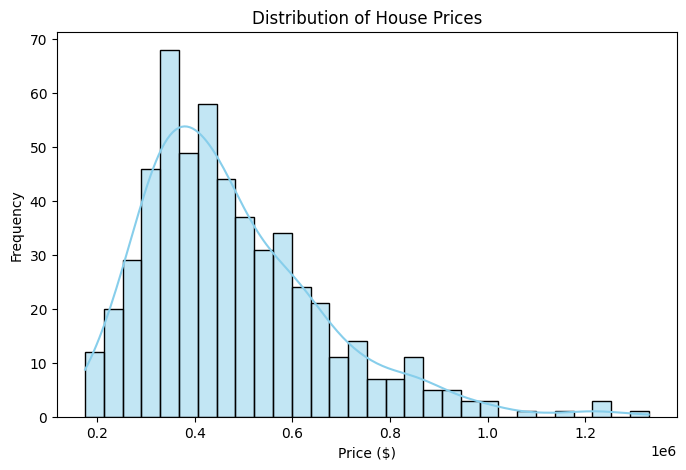

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['Price ($)'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of House Prices')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

### Target Distribution Analysis
- Price is right-skewed, with most values under 600,000.
- A small number of houses exceed $1 million, indicating outliers.
**Decision:** Consider log-transforming Price for regression models to reduce skewness and improve prediction stability.

### 2.2 Distribution of features

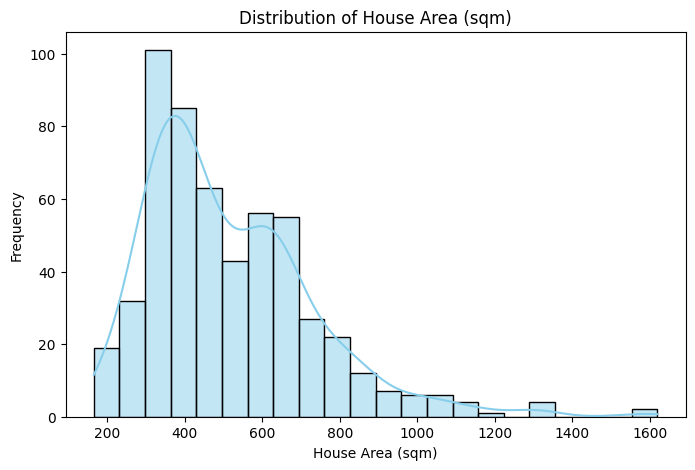

In [65]:
plt.figure(figsize=(8,5))
sns.histplot(df['House Area (sqm)'], kde=True, color='skyblue', edgecolor='black')
plt.title('Distribution of House Area (sqm)')
plt.xlabel('House Area (sqm)')
plt.ylabel('Frequency')
plt.show()

### Reflection: House Area Distribution
- The feature is right-skewed, with most houses between 200–500 sqm.
- A few large houses, 800+ sqm exist and may act as outliers.
- Should use log-transforming or binning House Area to improve model.

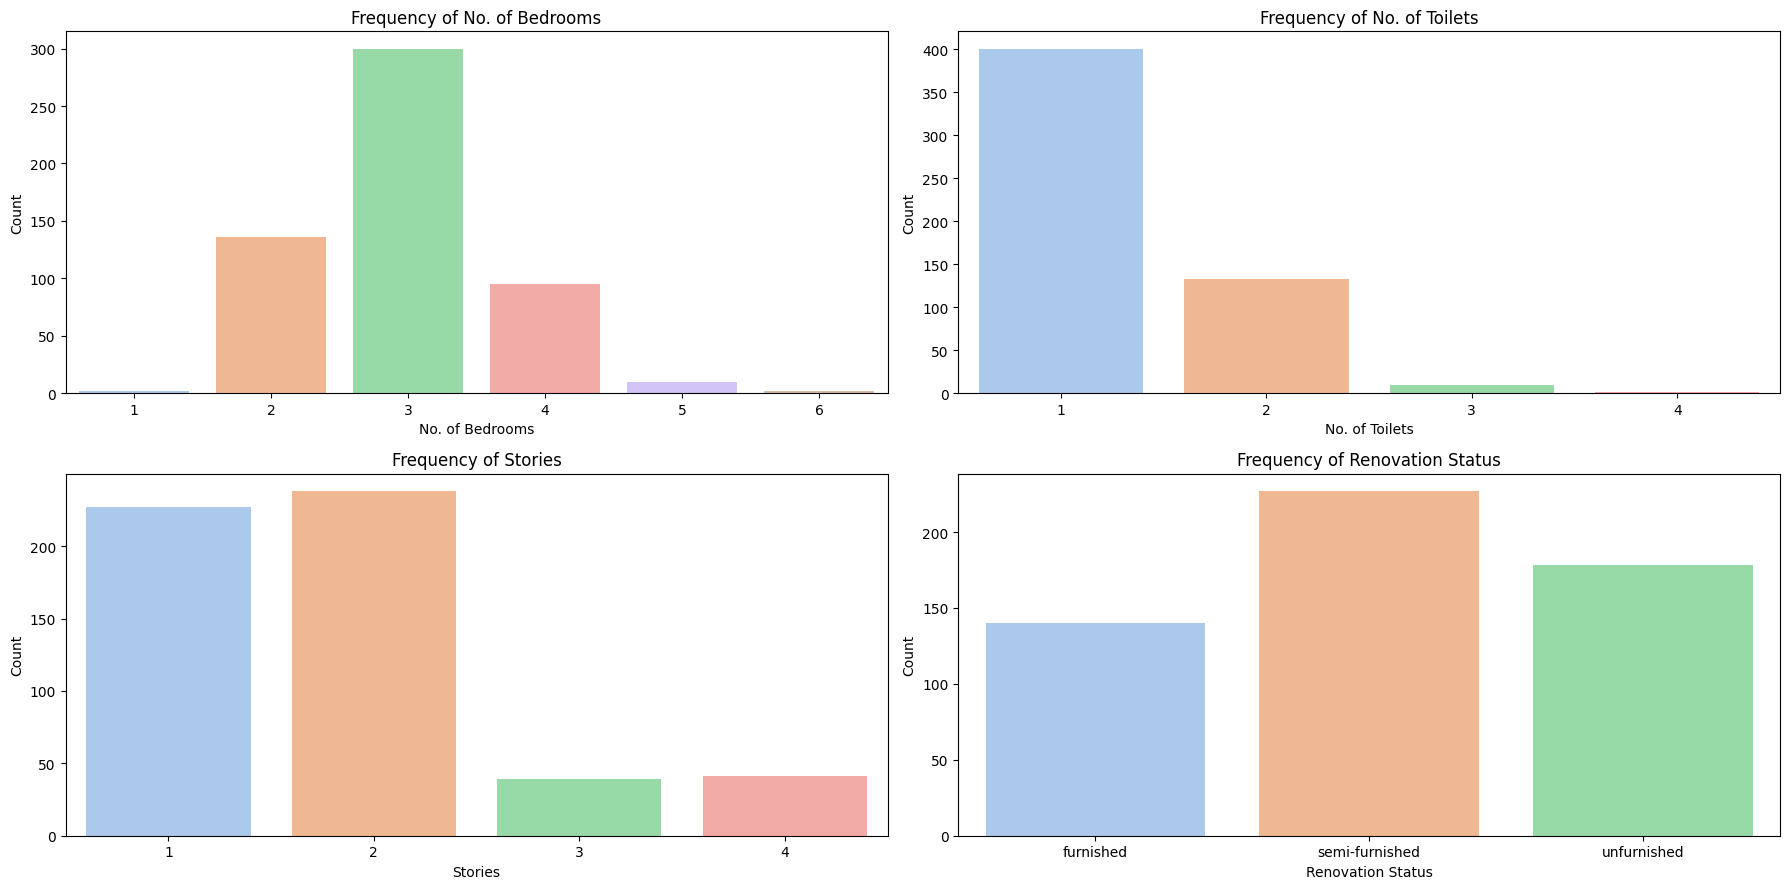

In [66]:
cols = ['No. of Bedrooms', 'No. of Toilets', 'Stories','Renovation Status']
fig, axes = plt.subplots(2, 2, figsize=(18, 9))  # 1 row, 3 columns
axes=axes.flatten()

for i, col in enumerate(cols):
    sns.countplot(x=col, data=df, palette='pastel', ax=axes[i])
    axes[i].set_title(f'Frequency of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()


### Discrete Feature Frequency Analysis
- Majority of houses have 2–4 bedrooms.
- 1,5 and 6 bedrooms are rare and may represent luxury listings.

- Most homes have 1–2 toilets, with very few having 3–4.

- Majority of houses are 1–2 stories.
- 3–4 story homes are less common but still have a considerable ammount.

In [67]:
target = 'Price ($)'
num_cols = ['House ID', 'House Area (sqm)', 'No. of Bedrooms', 'No. of Toilets', 'Stories']
cat_cols = ['City', 'Renovation Status']

# 1. Target correlation with numeric features
print("Correlation to target:")
for col in num_cols:
    corr = df[col].corr(df[target])
    print(f"{col}: {corr:.2f}")   # show correlation coefficient directly

# 2. Target relationship with categorical features
for col in cat_cols:
    print(f"\nMean Price by {col}:")
    grouped = df.groupby(col)[target].mean().sort_values(ascending=False)
    for category, mean_price in grouped.items():
        print(f"  {category}: ${mean_price:,.2f}")   # show mean price in dollars

Correlation to target:
House ID: -0.93
House Area (sqm): 0.54
No. of Bedrooms: 0.37
No. of Toilets: 0.52
Stories: 0.42

Mean Price by City:
  Denver: $504,589.89
  Chicago: $503,850.75
  Boston: $477,780.00
  New York: $464,753.48
  Seattle: $459,351.49

Mean Price by Renovation Status:
  furnished: $549,569.60
  semi-furnished: $490,752.42
  unfurnished: $401,383.15


### Correlation Insights
- House Area (0.54) and Toilets (0.52) are the strongest numeric predictors of price.
- Renovation Status shows a clear ordinal effect: furnished > semi-furnished > unfurnished.
- City strongly influences price, with Denver and Chicago highest.
- Drop House ID. Retain and encode City + Renovation Status. Expect House Area and Toilets to be key drivers in modeling.

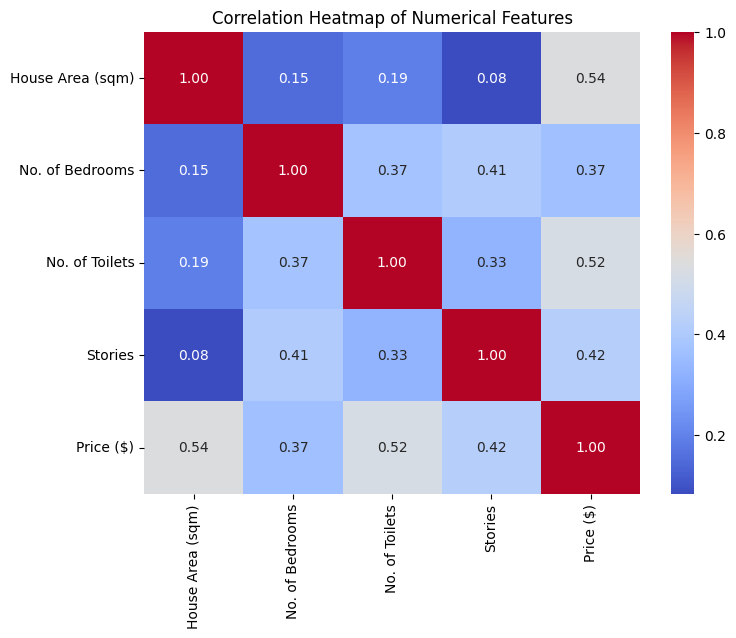

In [68]:
plt.figure(figsize=(8,6))
corr = df[['House Area (sqm)', 'No. of Bedrooms', 'No. of Toilets', 'Stories', 'Price ($)']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### 3. Imputation is not required in this dataset.

## 4. Feature preparation

### 4.1 Feature selection

In [5]:
df = df.drop(columns=['House ID'])

In [6]:
# Encode Renovation Status (ordinal)
df['Renovation Status'] = df['Renovation Status'].str.strip().str.lower()
df['Renovation Status'] = df['Renovation Status'].map({
    'unfurnished': 0,
    'semi-furnished': 1,
    'furnished': 2
})
df.head()

,City,House Area (sqm),No. of Bedrooms,No. of Toilets,Stories,Renovation Status,Price ($)
0,Chicago,742.0,4,2,3,2,1330000
1,Denver,896.0,4,4,4,2,1225000
2,Chicago,996.0,3,2,2,1,1225000
3,Seattle,750.0,4,2,2,2,1221500
4,New York,742.0,4,1,2,2,1141000


In [7]:
df = pd.get_dummies(df, columns=['City'], drop_first=True)
df.head()

,House Area (sqm),No. of Bedrooms,No. of Toilets,Stories,Renovation Status,Price ($),City_Chicago,City_Denver,City_New York,City_Seattle
0,742.0,4,2,3,2,1330000,True,False,False,False
1,896.0,4,4,4,2,1225000,False,True,False,False
2,996.0,3,2,2,1,1225000,True,False,False,False
3,750.0,4,2,2,2,1221500,False,False,False,True
4,742.0,4,1,2,2,1141000,False,False,True,False


### Scaling Decision for Regression
- House Area (sqm) has a much larger numeric range than other features.
- In regression, unscaled large features dominate coefficients and distort regularization penalties.
- Scaling ensures coefficients are comparable and improves model stability.
- Apply StandardScaler to House Area (sqm) after Train/test split. Leave categorical encodings unscaled.

### Train Test Split

In [8]:
X = df.drop('Price ($)', axis=1)   # all columns except target
y = df['Price ($)']                # target column

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (436, 9) Test size: (109, 9)


### 4.2 Dummy Baseline

In [9]:
dummy_reg = DummyRegressor(strategy="mean")
dummy_reg.fit(X_train, y_train)

# Predict
y_pred_dummy = dummy_reg.predict(X_test)

# Evaluate
print("Dummy Baseline Performance:")
print("MAE:", mean_absolute_error(y_test, y_pred_dummy))
print("MSE:", mean_squared_error(y_test, y_pred_dummy))
print("R²:", r2_score(y_test, y_pred_dummy))

Dummy Baseline Performance:
MAE: 174862.46069354427
MSE: 51451768522.26261
R²: -0.0179256794248297


#### Dummy Baseline Interpretation
- DummyRegressor (mean strategy) yields MAE ≈ $175k, MSE ≈ 5.1e10, R² ≈ -0.018.
- Negative R² indicates the baseline is worse than simply predicting the mean.
**Decision:** Use these metrics as a benchmark. Real regression models must outperform this baseline to be considered useful.

### 4.3 Normalization

In [10]:
# Initialize scaler
robust_scaler = RobustScaler()

# Fit on training set and transform only House Area
X_train_std = X_train.copy()
X_test_std = X_test.copy()

X_train_std['House Area (sqm)'] = robust_scaler.fit_transform(X_train[['House Area (sqm)']])
X_test_std['House Area (sqm)'] = robust_scaler.transform(X_test[['House Area (sqm)']])

# Check result
X_train_std.head()

,House Area (sqm),No. of Bedrooms,No. of Toilets,Stories,Renovation Status,City_Chicago,City_Denver,City_New York,City_Seattle
46,0.543478,3,2,4,2,False,False,True,False
93,0.978261,3,2,1,1,False,True,False,False
335,-0.247826,2,1,1,2,True,False,False,False
412,-0.684783,3,1,2,0,False,False,False,False
471,-0.271739,3,1,2,0,False,False,False,True


## 5. Model Selection

### 5.1 KNN

In [11]:
knn = KNeighborsRegressor(n_neighbors=9) 
knn.fit(X_train_std, y_train)
y_pred_knn = knn.predict(X_test_std)

print("KNN Regressor Performance:")
print("MAE:", mean_absolute_error(y_test, y_pred_knn))
print("MSE:", mean_squared_error(y_test, y_pred_knn))
print("R²:", r2_score(y_test, y_pred_knn))

KNN Regressor Performance:
MAE: 121181.70234454639
MSE: 28492172866.19595
R²: 0.43630869732761535


#### KNN Regressor Evaluation
- **MAE ($121k):** Average prediction error. Better than Dummy.
- **MSE (28.5B):** Squared error penalizes large mistakes. Shows KNN makes big errors.
- **R2 (0.44):** Explains 44% of variance.

- Outperforms Dummy baseline.
- Sensitive to choice of neighbors metric.


### 5.2 Linear Regression

In [24]:
linreg = LinearRegression()
linreg.fit(X_train_std, y_train)
y_pred_linreg = linreg.predict(X_test_std)

print("Linear Regression Performance:")
print("MAE:", mean_absolute_error(y_test, y_pred_linreg))
print("MSE:", mean_squared_error(y_test, y_pred_linreg))
print("R²:", r2_score(y_test, y_pred_linreg))

Linear Regression Performance:
MAE: 118060.62792998849
MSE: 24280979529.1471
R²: 0.5196232647744071


#### Linear Regression Evaluation
- **MAE ($118k):** Average prediction error. Better than Dummy and KNN.
- **MSE (24.3B):** Squared error penalizes large mistakes. Shows Linear Regression is more stable.
- **R2(0.52):** Explains 52% of variance. Stronger than KNN and Dummy.

  
**Decision:** Linear Regression is currently the best baseline model.

### 5.3 Decision Tree Regressor

In [73]:
dtree = DecisionTreeRegressor(max_depth=9, min_samples_leaf=9, random_state=42)
dtree.fit(X_train_std, y_train)
y_pred_dtree = dtree.predict(X_test_std)

print("Decision Tree Regressor Performance:")
print("MAE:", mean_absolute_error(y_test, y_pred_dtree))
print("MSE:", mean_squared_error(y_test, y_pred_dtree))
print("R²:", r2_score(y_test, y_pred_dtree))

Decision Tree Regressor Performance:
MAE: 125770.0438803117
MSE: 26063157725.426105
R²: 0.4843645165640619


#### Decision Tree Regressor Evaluation
- **MAE ($126k):** Average prediction error. Better than Dummy, worse than Linear/Ridge.
- **MSE (26.1B):** Squared error penalizes large mistakes. Shows Decision Tree makes bigger errors than Linear.
- **R2 (0.48):** Explains 48% of variance. Weaker than Linear/Ridge (52%), but stronger than Dummy.
**Decision:** Decision Tree is a useful non-linear baseline, but linear models remain more accurate and stable for this dataset.

### 5.4 SVR

In [29]:
svr = SVR(kernel='rbf', C=100, epsilon=5000, gamma='scale')
svr.fit(X_train_std, y_train)

y_pred_svr = svr.predict(X_test_std)

print("SVR Performance:")
print("MAE:", mean_absolute_error(y_test, y_pred_svr))
print("MSE:", mean_squared_error(y_test, y_pred_svr))
print("R²:", r2_score(y_test, y_pred_svr))

SVR Performance:
MAE: 174913.58998277815
MSE: 54771805096.42688
R²: -0.0836095340820151


#### Support Vector Regression (SVR) Evaluation
- MAE $175k, MSE 54.8B, R2 -0.08.
- Performance worse than Dummy baseline and all other models.
- Likely due to large target values and sensitivity to parameters.

**Decision:** SVR is not suitable for this dataset. Focus will remain on Linear Regression, Ridge, and Decision Tree/Random Forest for regression tasks.

### 5.5 Regularized Model: Ridge Regression

In [25]:
ridge = Ridge(alpha=1) 
ridge.fit(X_train_std, y_train)

y_pred_ridge = ridge.predict(X_test_std)

print("Ridge Regression Performance:")
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("R²:", r2_score(y_test, y_pred_ridge))


Ridge Regression Performance:
MAE: 117943.63554738274
MSE: 24272938787.573673
R²: 0.5197823434137676


#### Ridge Regression Evaluation

- **MAE ( $118k):** Average prediction error. Slightly better than Linear Regression.
- **MSE ( 24.27B):** Squared error penalizes large mistakes. Nearly identical to Linear Regression.
- **R2 ( 0.52):** Explains 52% of variance. Matches Linear Regression.

### 5.6 Regularized Model: Lasso Regression

In [31]:
lasso = Lasso(alpha=0.1, random_state=42)
lasso.fit(X_train_std, y_train)

y_pred_lasso = lasso.predict(X_test_std)

print("Lasso Regression Performance:")
print("MAE:", mean_absolute_error(y_test, y_pred_lasso))
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("R²:", r2_score(y_test, y_pred_lasso))

Lasso Regression Performance:
MAE: 118060.49928559216
MSE: 24280956922.93823
R²: 0.5196237120173529


#### Lasso Regression Evaluation
- **MAE ($118k):** Average prediction error. Matches Linear and Ridge.
- **MSE (24.28B):** Squared error penalizes large mistakes. Same stability as Linear and Ridge.
- **R2 (0.52):** Explains 52% of variance. Matches other linear models.

##### As far as we test, Ridge regression is the best model.

## 6. Tuning and Improving models

### 6.1 Checking Feature Importance/ Coefficients

In [42]:
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_std, y_train)

# Collect coefficients
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': ridge.coef_,
    'Importance (abs)': np.abs(ridge.coef_)
}).sort_values(by='Importance (abs)', ascending=False)

print(coef_df)


             Feature    Coefficient  Importance (abs)
2     No. of Toilets  122288.483585     122288.483585
0   House Area (sqm)   91508.680285      91508.680285
3            Stories   44682.750514      44682.750514
4  Renovation Status   38158.405572      38158.405572
1    No. of Bedrooms   16004.606634      16004.606634
7      City_New York    9730.575265       9730.575265
6        City_Denver    8504.336154       8504.336154
5       City_Chicago   -7418.440729       7418.440729
8       City_Seattle    -154.335674        154.335674


#### Ridge Regression Feature Importance Reflection
- **No. of Toilets (~122k)** and **House Area (~91k)** are the strongest drivers of price.  
- **Stories (~45k)** and **Renovation (~38k)** have moderate influence.  
- **Bedrooms (~16k)** add value but less significantly.  
- **City dummies** show minor effects: New York (+9.7k), Denver (+8.5k), Chicago (-7.4k).  
- **Seattle (~0)** is negligible and can be safely dropped.  
**Decision:** Structural features dominate predictions, while city effects are weak. Focus on core housing attributes.

In [44]:
# Drop specific columns
X_train_reduced = X_train_std.drop(columns=['City_Seattle', 'City_Chicago', 'City_Denver', 'City_New York'])
X_test_reduced  = X_test_std.drop(columns=['City_Seattle', 'City_Chicago', 'City_Denver', 'City_New York'])

#### Dropping City Dummies
- Removed weak city dummy variables (Seattle, Chicago, Denver, New York) from the dataset.  
- These features had low or negligible importance compared to structural attributes.  

### 6.2 Tuning with original data 

In [36]:
param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100, 1000]
}

ridge = Ridge(random_state=42)
grid = GridSearchCV(ridge, param_grid, cv=5, scoring='r2')
grid.fit(X_train_std, y_train)

print("Best alpha:", grid.best_params_)
print("Best R²:", grid.best_score_)

Best alpha: {'alpha': 10}
Best R²: 0.5198067844894744


### 6.3 Tuning without city dummies

In [45]:
param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100, 1000]
}

ridge = Ridge(random_state=42)
grid = GridSearchCV(ridge, param_grid, cv=5, scoring='r2')
grid.fit(X_train_reduced, y_train)

print("Best alpha:", grid.best_params_)
print("Best R²:", grid.best_score_)

Best alpha: {'alpha': 10}
Best R²: 0.5286055157290311


### 6.4 Testing model with best parameter

In [51]:
ridge = Ridge(alpha=10) 
ridge.fit(X_train_reduced, y_train)

y_pred_ridge = ridge.predict(X_test_reduced)

print("Ridge Regression Performance:")
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("R²:", r2_score(y_test, y_pred_ridge))


Ridge Regression Performance:
MAE: 115884.44001419633
MSE: 23992023309.718975
R²: 0.5253399964715524


## Final Conclusion

- After testing multiple models (Linear, Lasso, Decision Tree, KNN, SVR), **Ridge Regression** delivered the best accuracy.
- **Performance:**  
  - MAE 115,884 - average prediction error in house price.  
  - MSE 2.40 × 10¹⁰ - large errors penalized more heavily.  
  - R2 0.525 - model explains 52.5% of the variance in house prices.  
- Dropping weak city dummies improved generalization and simplified interpretation.  
- Structural features (toilets, area, stories, renovation, bedrooms) dominate predictions, while city effects are minor.  

**Decision:** Ridge Regression tuned with gridsearch is the chosen final model. 